In [ ]:
###for training###

In [5]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm


In [21]:
dataset_path = r'C:\Users\QADEESA\New folder\Documents\Desktop\23-bsai-068, 23-bsai-116\dataset'

In [22]:
training_set = datagen.flow_from_directory(
    r'C:\Users\QADEESA\New folder\Documents\Desktop\23-bsai-068, 23-bsai-116\dataset',
    target_size=(64, 64),
    batch_size=32
)


Found 250 images belonging to 10 classes.


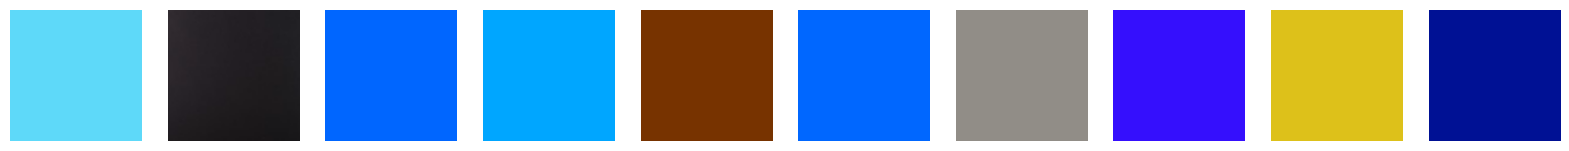

In [25]:
n = 10
plt.figure(figsize=(20, 4))

# Get a batch of images and labels
images, labels = next(training_set)

for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    image_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

    # Since pixel values are already in the range [0, 1], no further rescaling is needed
    # If needed, you can multiply by 255 to display in [0, 255] range
    image_rgb = (image_rgb * 255).astype(np.uint8)  # Rescale back to [0, 255] for visualization

    plt.imshow(image_rgb)
    plt.axis('off')  # Hide axes for better visualization

plt.show()


In [28]:
rgb = []
color = []
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        # Read the image and convert to RGB
        image = cv2.cvtColor(cv2.imread(os.path.join(dirname, filename)), cv2.COLOR_BGR2RGB)
        
        # Store the RGB value from the top-left corner of the image
        rgb.append(image[0][0])
        
        # Store the directory name (just the folder name, not the full path)
        color.append(dirname.split(os.sep)[-1])


In [29]:
x = pd.DataFrame(np.array(rgb), columns=['red', 'green', 'blue'])
y = pd.DataFrame({'color': color})
print(x)
print(y)

     red  green  blue
0     10      5     2
1     17      0    17
2     29     24    23
3     47     47    47
4     28     29    33
..   ...    ...   ...
245  255    255   255
246  255    255     0
247  255    166     0
248  249    217    94
249  246    191    39

[250 rows x 3 columns]
      color
0     black
1     black
2     black
3     black
4     black
..      ...
245  yellow
246  yellow
247  yellow
248  yellow
249  yellow

[250 rows x 1 columns]


In [30]:
x = np.array(x)
y = np.array(y)
# y =  y.reshape(250,)
print(x.shape)
print(y.shape)


(250, 3)
(250, 1)


In [31]:
from sklearn.preprocessing import LabelEncoder

# Assuming y is your target labels, flatten it if it's 2D
y = y.ravel()  # This flattens y to a 1D array

# Now you can apply LabelEncoder
label_encoder = LabelEncoder()
encoded_y = label_encoder.fit_transform(y)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(x, encoded_y, test_size=0.35, random_state=0)
print("X train shape: ",X_train.shape)
print("y train shape: ",y_train.shape)
print("X test shape: ",X_test.shape)
print("y test shape: ",y_test.shape)

X train shape:  (162, 3)
y train shape:  (162,)
X test shape:  (88, 3)
y test shape:  (88,)


In [33]:
model = LogisticRegression(solver='liblinear', random_state=0).fit(X_train,y_train)
print("Test Accuracy",(model.score(X_test,y_test))*100)

Test Accuracy 75.0


In [46]:
###for testing is model is trained with perfectly ###

In [35]:
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

# Load the trained model
model = LogisticRegression(solver='liblinear', random_state=0)
model.fit(X_train, y_train)  

# Load the new image to be tested
test_image_path = 'image.png' 
image = cv2.imread(test_image_path)

#  Convert the image to RGB format
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Extract the RGB value from the top-left corner or other method to get the RGB value
rgb_value = image_rgb[0][0]  # This gives you the RGB value of the top-left pixel

# Prepare the image data for the model (reshape it to match the model's input format)
x_new = np.array(rgb_value).reshape(1, -1)  # Reshape to a single sample (1x3)

# Use the trained model to make a prediction
prediction = model.predict(x_new)

# Decode the prediction back to the color label
decoded_color = label_encoder.inverse_transform(prediction)

print(f"The predicted color is: {decoded_color[0]}")
cv2.imshow('window',image)
cv2.waitKey(0)



The predicted color is: violet


-1